# Huấn luyện supervised 3 lớp từ một cảm biến siêu âm

Notebook này so sánh nhiều mô hình cho ba nhãn:

- `SAFE`: gồm dữ liệu gốc `SAFE`, `RETREATING` và `EMPTY`. `EMPTY` nghĩa là không có người và không có vật.
- `APPROACHING`: người đang tiến lại gần cảm biến.
- `EMERGENCY`: dữ liệu gốc `DANGER`.

Điểm quan trọng: các dòng trong cùng một recording là chuỗi thời gian liên tục, vì vậy notebook **chia train/test theo `source_file`**, không chia ngẫu nhiên từng dòng.

Mục tiêu đánh giá ưu tiên là `macro F1` và `recall` của `EMERGENCY`. Hard safety rule vẫn độc lập với AI: khoảng cách rất gần không được phép bị mô hình hạ mức cảnh báo.

## 1. Cài đặt và import

Nếu chạy trên máy chưa có thư viện, bỏ comment dòng cài đặt bên dưới. Trên ESP32, notebook này được dùng để train/export model; không nên hiểu rằng file `joblib` có thể chạy trực tiếp trên ESP32.

In [5]:
# Nếu cần, chạy một lần:
# %pip install pandas numpy scikit-learn matplotlib seaborn joblib

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
LABEL_ORDER = ["SAFE", "APPROACHING", "EMERGENCY"]


## 2. Tìm và đọc dataset đã xử lý

In [6]:
def find_dataset():
    candidates = [
        Path.cwd() / "ai_model/data/single_sensor/processed_3class/dataset_3class.csv",
        Path.cwd().parent / "data/single_sensor/processed_3class/dataset_3class.csv",
        Path.cwd().parent.parent / "ai_model/data/single_sensor/processed_3class/dataset_3class.csv",
        Path("/kaggle/input/single-sensor-dataset/processed_3class/dataset_3class.csv"),
        Path("/kaggle/working/single_sensor_dataset/processed_3class/dataset_3class.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    # Fallback: tìm trong các thư mục Kaggle input.
    for root in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if root.exists():
            matches = list(root.rglob("dataset_3class.csv"))
            if matches:
                return matches[0]
    raise FileNotFoundError(
        "Không tìm thấy dataset_3class.csv. Hãy đặt dataset vào "
        "ai_model/data/single_sensor/processed_3class/"
    )

data_path = find_dataset()
df = pd.read_csv(data_path)
required = {"source_file", "elapsed_s", "distance_cm", "original_label", "label"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Thiếu cột: {sorted(missing)}")

df["elapsed_s"] = pd.to_numeric(df["elapsed_s"], errors="coerce")
df["distance_cm"] = pd.to_numeric(df["distance_cm"], errors="coerce")
df = df.dropna(subset=["source_file", "elapsed_s", "distance_cm", "label"]).copy()
df["label"] = df["label"].astype(str).str.upper()
if set(df["label"].unique()) != set(LABEL_ORDER):
    raise ValueError(f"Nhãn không đúng: {sorted(df['label'].unique())}")

print("Dataset:", data_path)
print("Số dòng:", len(df))
print("Số recording:", df["source_file"].nunique())
print(df["label"].value_counts().reindex(LABEL_ORDER).to_string())


Dataset: /kaggle/input/datasets/nguyntrnminhc/blockchainn/processed_3class/dataset_3class.csv
Số dòng: 1874
Số recording: 17
label
SAFE           1196
APPROACHING     264
EMERGENCY       414


In [7]:
# Kiểm tra mapping nhãn gốc -> nhãn train.
print(pd.crosstab(df["original_label"], df["label"]).reindex(columns=LABEL_ORDER, fill_value=0).to_string())


label           SAFE  APPROACHING  EMERGENCY
original_label                              
APPROACHING        0          264          0
DANGER             0            0        414
EMPTY            102            0          0
RETREATING       598            0          0
SAFE             496            0          0


## 3. Tạo đặc trưng theo thời gian

Một mẫu đơn chỉ có khoảng cách chưa đủ để phân biệt `SAFE` và `APPROACHING`. Ta thêm vận tốc thay đổi khoảng cách trong cùng recording và các thống kê cửa sổ quá khứ.

Quy ước: vận tốc dương nghĩa là khoảng cách tăng, tức là đối tượng đang rời xa; vận tốc âm nghĩa là đang tiến lại gần.

In [8]:
def make_features(frame):
    out = frame.sort_values(["source_file", "elapsed_s"]).copy()
    grouped = out.groupby("source_file", sort=False)
    dt = grouped["elapsed_s"].diff()
    dd = grouped["distance_cm"].diff()
    out["approach_speed_cm_s"] = (dd / dt.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    # Loại nhiễu cực đoan ở đạo hàm do mẫu thời gian bất thường; khoảng cách gốc vẫn giữ nguyên.
    out["approach_speed_cm_s"] = out["approach_speed_cm_s"].clip(-500, 500).fillna(0.0)
    out["distance_delta_3"] = grouped["distance_cm"].diff(3).fillna(0.0)
    out["distance_std_5"] = grouped["distance_cm"].transform(
        lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
    )
    out["distance_mean_5"] = grouped["distance_cm"].transform(
        lambda s: s.rolling(5, min_periods=1).mean()
    )
    out["speed_mean_5"] = grouped["approach_speed_cm_s"].transform(
        lambda s: s.rolling(5, min_periods=1).mean()
    )
    return out

feature_df = make_features(df)
FEATURE_COLUMNS = [
    "distance_cm", "approach_speed_cm_s", "distance_delta_3",
    "distance_std_5", "distance_mean_5", "speed_mean_5",
]
X = feature_df[FEATURE_COLUMNS].astype(float)
y = feature_df["label"]
groups = feature_df["source_file"]
print(feature_df[FEATURE_COLUMNS].describe().round(2).to_string())


       distance_cm  approach_speed_cm_s  distance_delta_3  distance_std_5  distance_mean_5  speed_mean_5
count      1874.00              1874.00           1874.00         1874.00          1874.00       1874.00
mean        114.23                 0.74              0.78            3.36           113.72          0.78
std          69.18                64.38              9.95            6.13            69.17         21.44
min          18.30              -500.00           -117.30            0.00            18.90       -300.00
25%          48.20                -2.73             -0.60            0.44            46.56         -0.86
50%         103.45                 0.00              0.00            1.08           103.23          0.01
75%         164.20                 6.53              2.30            3.64           162.72          5.93
max         274.20               500.00            115.50           52.06           248.90        220.00


## 4. Kiểm tra nhanh dữ liệu

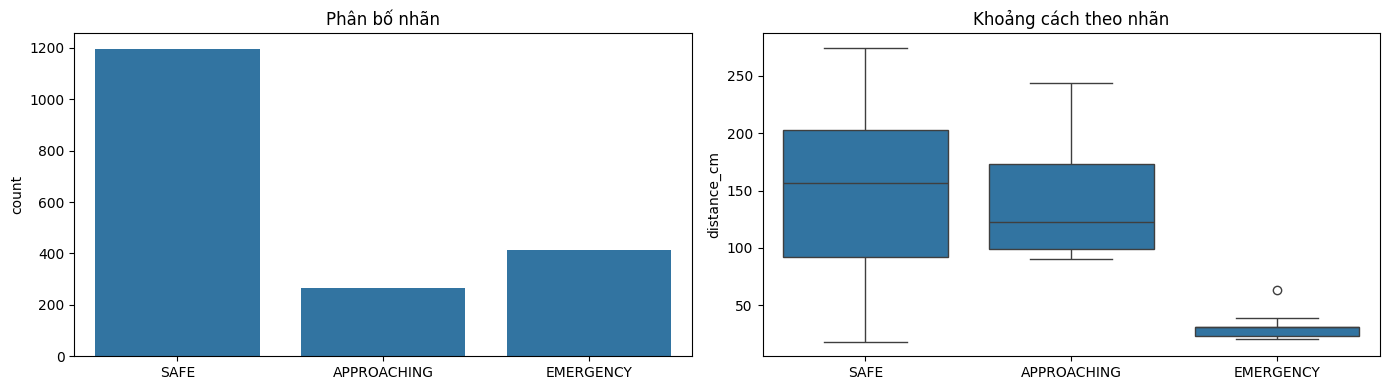

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=feature_df, x="label", order=LABEL_ORDER, ax=axes[0])
axes[0].set_title("Phân bố nhãn")
axes[0].set_xlabel("")

sns.boxplot(data=feature_df, x="label", y="distance_cm", order=LABEL_ORDER, ax=axes[1])
axes[1].set_title("Khoảng cách theo nhãn")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()


## 5. Chia nhóm và định nghĩa các mô hình

`StratifiedGroupKFold` bảo đảm các dòng của một recording không bị rơi vào cả train và validation. Vì mỗi recording hiện chỉ có một nhãn, đây là cách chia bảo thủ hơn so với chia từng dòng.

In [10]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(cv.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Train rows:", len(X_train), "Test rows:", len(X_test))
print("Train recordings:", g_train.nunique(), "Test recordings:", g_test.nunique())
print("Train labels:", y_train.value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict())
print("Test labels:", y_test.value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict())
print("Test recordings:", sorted(g_test.unique()))

models = {
    "logistic_regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_iter=150, learning_rate=0.05, max_leaf_nodes=15,
        l2_regularization=1.0, random_state=RANDOM_STATE
    ),
}


Train rows: 1512 Test rows: 362
Train recordings: 14 Test recordings: 3
Train labels: {'SAFE': 1090, 'APPROACHING': 167, 'EMERGENCY': 255}
Test labels: {'SAFE': 106, 'APPROACHING': 97, 'EMERGENCY': 159}
Test recordings: ['son2_roi_50ve200_cham_RETREATING.csv', 'son_ghe_30_DANGER.csv', 'son_tien_200ve100_cham_APPROACHING.csv']


## 6. So sánh mô hình trên test set theo recording

In [11]:
def metrics_row(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, labels=LABEL_ORDER, output_dict=True, zero_division=0)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": report["macro avg"]["f1-score"],
        "emergency_recall": report["EMERGENCY"]["recall"],
        "emergency_precision": report["EMERGENCY"]["precision"],
    }

results = []
predictions = {}
for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    pred = fitted.predict(X_test)
    predictions[name] = pred
    results.append(metrics_row(name, y_test, pred))

results_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "emergency_recall", "balanced_accuracy"], ascending=False
).reset_index(drop=True)
results_df.round(4)


,model,accuracy,balanced_accuracy,macro_f1,emergency_recall,emergency_precision
0,extra_trees,0.9144,0.8938,0.8945,1.0,1.0000
1,hist_gradient_boosting,0.8867,0.8603,0.8593,1.0,1.0000
2,random_forest,0.8619,0.8296,0.8256,1.0,1.0000
3,logistic_regression,0.8398,0.8033,0.7987,1.0,0.9408


Model tốt nhất theo macro F1: extra_trees
              precision    recall  f1-score   support

        SAFE       0.78      0.99      0.87       106
 APPROACHING       0.99      0.69      0.81        97
   EMERGENCY       1.00      1.00      1.00       159

    accuracy                           0.91       362
   macro avg       0.92      0.89      0.89       362
weighted avg       0.93      0.91      0.91       362



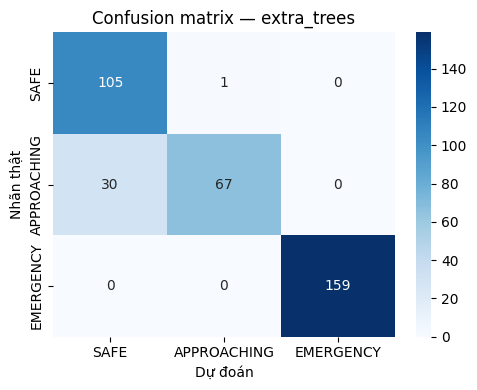

In [12]:
best_name = results_df.iloc[0]["model"]
best_model = clone(models[best_name])
best_model.fit(X_train, y_train)
best_pred = predictions[best_name]
print("Model tốt nhất theo macro F1:", best_name)
print(classification_report(y_test, best_pred, labels=LABEL_ORDER, zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=LABEL_ORDER)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER)
plt.xlabel("Dự đoán")
plt.ylabel("Nhãn thật")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 7. Cross-validation theo recording

Một lần chia holdout chỉ cho một góc nhìn. Cell này tính điểm trung bình qua 5 fold; nếu số recording tăng lên, kết quả này sẽ đáng tin cậy hơn.

In [13]:
cv_results = []
for name, model in models.items():
    fold_rows = []
    for fold, (tr, va) in enumerate(cv.split(X, y, groups=groups), start=1):
        fitted = clone(model)
        fitted.fit(X.iloc[tr], y.iloc[tr])
        pred = fitted.predict(X.iloc[va])
        row = metrics_row(name, y.iloc[va], pred)
        row["fold"] = fold
        fold_rows.append(row)
    cv_results.extend(fold_rows)

cv_results_df = pd.DataFrame(cv_results)
cv_summary = (cv_results_df.groupby("model")[["accuracy", "balanced_accuracy", "macro_f1", "emergency_recall", "emergency_precision"]]
              .agg(["mean", "std"]).sort_values(("macro_f1", "mean"), ascending=False))
cv_summary.round(4)


accuracy         balanced_accuracy         macro_f1  \
                           mean     std              mean     std     mean   
model                                                                        
hist_gradient_boosting   0.7967  0.1501            0.7950  0.1422   0.5536   
logistic_regression      0.6767  0.1955            0.6855  0.1833   0.4983   
extra_trees              0.7139  0.2277            0.6929  0.2476   0.4916   
random_forest            0.7586  0.1409            0.7360  0.1744   0.4834   

                               emergency_recall         emergency_precision  \
                           std             mean     std                mean   
model                                                                         
hist_gradient_boosting  0.2723           0.5275  0.4873              0.5864   
logistic_regression     0.3021           0.5926  0.5412              0.4869   
extra_trees             0.3372           0.3708  0.5069              0.4143   
random_forest           0.2838           0.3618  0.5000              0.4000   

                                
                           std  
model                           
hist_gradient_boosting  0.5360  
logistic_regression     0.4857  
extra_trees             0.5355  
random_forest           0.5477

## 8. Huấn luyện model cuối và lưu artifact

Model được train lại trên toàn bộ dataset sau khi chọn kiến trúc. Artifact chứa feature order, mapping nhãn và ngưỡng bảo vệ để gateway dùng nhất quán.

In [14]:
# Chọn theo điểm CV macro F1 trung bình; nếu hòa, ưu tiên recall EMERGENCY.
model_order = (cv_results_df.groupby("model")[["macro_f1", "emergency_recall", "balanced_accuracy"]]
               .mean().sort_values(["macro_f1", "emergency_recall", "balanced_accuracy"], ascending=False))
final_name = model_order.index[0]
final_model = clone(models[final_name])
final_model.fit(X, y)

artifact_dir = Path.cwd() / "ai_model/artifacts"
if not artifact_dir.exists():
    artifact_dir = Path.cwd().parent / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": final_model,
    "model_name": final_name,
    "feature_columns": FEATURE_COLUMNS,
    "label_order": LABEL_ORDER,
    "label_mapping": {"SAFE": 0, "APPROACHING": 1, "EMERGENCY": 2},
    "thresholds_cm": {"emergency_hard": 30.0, "warning": 60.0},
    "training_rows": int(len(X)),
    "training_recordings": int(groups.nunique()),
    "original_label_mapping": {
        "DANGER": "EMERGENCY",
        "APPROACHING": "APPROACHING",
        "SAFE": "SAFE",
        "RETREATING": "SAFE",
        "EMPTY": "SAFE",
    },
}
model_path = artifact_dir / "single_sensor_3class_best.joblib"
metrics_path = artifact_dir / "single_sensor_3class_metrics.json"
joblib.dump(artifact, model_path)
metrics_payload = {
    "selected_model": final_name,
    "feature_columns": FEATURE_COLUMNS,
    "holdout_results": results_df.to_dict(orient="records"),
    "cross_validation_summary": json.loads(cv_summary.round(6).to_json()),
    "labels": LABEL_ORDER,
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")
print("Đã lưu model:", model_path)
print("Đã lưu metrics:", metrics_path)


Đã lưu model: /kaggle/artifacts/single_sensor_3class_best.joblib
Đã lưu metrics: /kaggle/artifacts/single_sensor_3class_metrics.json


## 9. Hàm dự đoán dùng chung cho gateway

Trong hệ thống thật, gateway cần duy trì khoảng cách trước đó và một buffer ngắn để tạo đúng feature. Phần hard rule được áp dụng trước dự đoán AI.

In [15]:
def predict_measurement(distance_cm, previous_distance_cm=None, dt_s=0.18):
    distance_cm = float(distance_cm)
    previous = distance_cm if previous_distance_cm is None else float(previous_distance_cm)
    speed = (distance_cm - previous) / max(float(dt_s), 1e-6)
    row = pd.DataFrame([{
        "distance_cm": distance_cm,
        "approach_speed_cm_s": np.clip(speed, -500, 500),
        # Với dự đoán online tối giản, dùng giá trị hiện tại làm fallback cho cửa sổ chưa đầy.
        "distance_delta_3": distance_cm - previous,
        "distance_std_5": 0.0,
        "distance_mean_5": distance_cm,
        "speed_mean_5": np.clip(speed, -500, 500),
    }])[FEATURE_COLUMNS]
    ai_label = final_model.predict(row)[0]
    # Không cho AI hạ emergency do ngưỡng cứng.
    if distance_cm <= 30.0:
        return {"label": "EMERGENCY", "emergency_stop": True, "ai_label": ai_label, "reason": "hard_distance_rule"}
    return {"label": ai_label, "emergency_stop": False, "ai_label": ai_label, "reason": "ai_prediction"}

for distance, previous in [(25, 28), (100, 120), (160, 160)]:
    print(distance, previous, "->", predict_measurement(distance, previous))


25 28 -> {'label': 'EMERGENCY', 'emergency_stop': True, 'ai_label': 'EMERGENCY', 'reason': 'hard_distance_rule'}
100 120 -> {'label': 'APPROACHING', 'emergency_stop': False, 'ai_label': 'APPROACHING', 'reason': 'ai_prediction'}
160 160 -> {'label': 'SAFE', 'emergency_stop': False, 'ai_label': 'SAFE', 'reason': 'ai_prediction'}


## 10. Tiêu chí trước khi triển khai

Không nên triển khai chỉ dựa trên accuracy. Cần kiểm tra riêng recall của `EMERGENCY`, false negative trong confusion matrix, dữ liệu ở điều kiện ánh sáng/nhiệt độ/vật liệu khác nhau và dữ liệu ghi trực tiếp từ đúng cảm biến trên ESP32. Khi chạy thực tế, nếu cảm biến lỗi hoặc mất mẫu, hệ thống nên chuyển sang trạng thái an toàn thay vì coi đó là `SAFE`.


# 11. Train Keras và export TensorFlow Lite INT8 cho ESP32

Các cell dưới đây chạy trên Kaggle. Chúng dùng cùng `feature_df`, `X`, `y`, `groups` và cách chia recording ở các cell trước. Kết quả được ghi vào `/kaggle/working/esp32_export`.

Model nhỏ dùng kiến trúc 6 → Dense(4) → Dense(3), có augmentation nhiễu ± khoảng 1 cm chỉ trên train split. Model được chuẩn hóa ở Python trước khi đưa vào Keras; các giá trị `feature_mean` và `feature_scale` cũng được xuất sang C++ để ESP32 thực hiện đúng preprocessing.


In [16]:
# Cài TensorFlow trên Kaggle nếu runtime chưa có. Chạy một lần nếu cần.
# %pip install -q tensorflow

import os
import shutil
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

tf.keras.utils.set_random_seed(RANDOM_STATE)
LABEL_TO_ID = {label: i for i, label in enumerate(LABEL_ORDER)}

# Dùng đúng split theo recording đã tạo ở cell 5; không split ngẫu nhiên từng dòng.
X_np = X.to_numpy(dtype=np.float32)
y_np = y.map(LABEL_TO_ID).to_numpy(dtype=np.int32)
X_train_np = X_np[train_idx]
y_train_np = y_np[train_idx]
X_test_np = X_np[test_idx]
y_test_np = y_np[test_idx]

feature_mean = X_train_np.mean(axis=0).astype(np.float32)
feature_scale = X_train_np.std(axis=0).astype(np.float32)
feature_scale = np.where(feature_scale < 1e-6, 1.0, feature_scale).astype(np.float32)
X_train_norm = ((X_train_np - feature_mean) / feature_scale).astype(np.float32)
X_test_norm = ((X_test_np - feature_mean) / feature_scale).astype(np.float32)
X_all_norm = ((X_np - feature_mean) / feature_scale).astype(np.float32)

class_weights_values = compute_class_weight(
    class_weight="balanced", classes=np.arange(len(LABEL_ORDER)), y=y_train_np
)
class_weights = {i: float(value) for i, value in enumerate(class_weights_values)}

print("Train shape:", X_train_norm.shape)
print("Test shape:", X_test_norm.shape)
print("Feature mean:", feature_mean)
print("Feature scale:", feature_scale)
print("Class weights:", class_weights)


Train shape: (1512, 6)
Test shape: (362, 6)
Feature mean: [120.71943      1.2728714    0.85959005   3.7338011  120.14737
   1.3376243 ]
Feature scale: [69.29098   55.56636   10.832266   6.6917925 69.32501   14.007822 ]
Class weights: {0: 0.46238532110091746, 1: 3.0179640718562872, 2: 1.9764705882352942}


In [17]:
def make_keras_model():
    # Model nhỏ hơn để giảm overfitting với chỉ 17 recording.
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(len(FEATURE_COLUMNS),), dtype=tf.float32),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(len(LABEL_ORDER), activation="softmax"),
    ], name="ultrasonic_safety_classifier")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Tăng cường chỉ trên train split; test recording giữ nguyên để đánh giá công bằng.
# Nhiễu Gaussian sigma=1 cm mô phỏng dao động nhỏ của cảm biến siêu âm.
AUGMENT_COPIES = 3
augmented_train = []
for _ in range(AUGMENT_COPIES):
    noisy = X_train_np.copy()
    noisy[:, 0] = noisy[:, 0] + np.random.normal(0.0, 1.0, size=len(noisy))
    augmented_train.append(noisy)

X_train_aug_np = np.concatenate([X_train_np] + augmented_train, axis=0)
y_train_aug = np.tile(y_train_np, AUGMENT_COPIES + 1)
X_train_aug_norm = ((X_train_aug_np - feature_mean) / feature_scale).astype(np.float32)

print("Original train:", X_train_np.shape)
print("Augmented train:", X_train_aug_norm.shape)

keras_model = make_keras_model()
history = keras_model.fit(
    X_train_aug_norm, y_train_aug,
    validation_data=(X_test_norm, y_test_np),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )],
    verbose=2,
)

print("Keras test metrics:", keras_model.evaluate(X_test_norm, y_test_np, verbose=0))


Original train: (1512, 6)
Augmented train: (6048, 6)


I0000 00:00:1791159946.838871      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791159946.843080      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1791159951.880609     345 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


189/189 - 3s - 17ms/step - accuracy: 0.3803 - loss: 1.1729 - val_accuracy: 0.5746 - val_loss: 1.2146
Epoch 2/100
189/189 - 1s - 3ms/step - accuracy: 0.4425 - loss: 1.0094 - val_accuracy: 0.6796 - val_loss: 1.0510
Epoch 3/100
189/189 - 1s - 3ms/step - accuracy: 0.5177 - loss: 0.8744 - val_accuracy: 0.7569 - val_loss: 0.9238
Epoch 4/100
189/189 - 0s - 3ms/step - accuracy: 0.6653 - loss: 0.7579 - val_accuracy: 0.8508 - val_loss: 0.8365
Epoch 5/100
189/189 - 1s - 3ms/step - accuracy: 0.7571 - loss: 0.6671 - val_accuracy: 0.8315 - val_loss: 0.7695
Epoch 6/100
189/189 - 1s - 3ms/step - accuracy: 0.7799 - loss: 0.6011 - val_accuracy: 0.8398 - val_loss: 0.7180
Epoch 7/100
189/189 - 1s - 3ms/step - accuracy: 0.7812 - loss: 0.5534 - val_accuracy: 0.8398 - val_loss: 0.6784
Epoch 8/100
189/189 - 1s - 3ms/step - accuracy: 0.7862 - loss: 0.5164 - val_accuracy: 0.8425 - val_loss: 0.6531
Epoch 9/100
189/189 - 1s - 3ms/step - accuracy: 0.7841 - loss: 0.4868 - val_accuracy: 0.8536 - val_loss: 0.6368
Epo

              precision    recall  f1-score   support

        SAFE       0.77      0.90      0.83       106
 APPROACHING       0.99      0.70      0.82        97
   EMERGENCY       0.94      1.00      0.97       159

    accuracy                           0.89       362
   macro avg       0.90      0.87      0.87       362
weighted avg       0.90      0.89      0.89       362



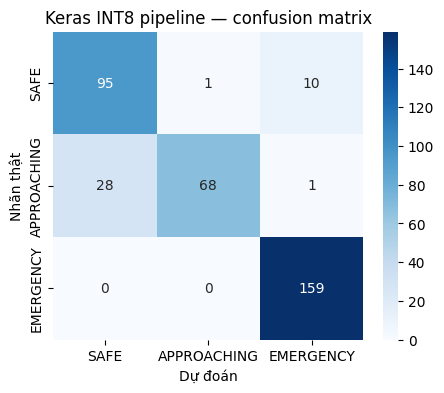

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_probabilities = keras_model.predict(X_test_norm, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)

print(classification_report(
    y_test_np,
    test_predictions,
    labels=[0, 1, 2],
    target_names=LABEL_ORDER,
    zero_division=0
))

cm = confusion_matrix(
    y_test_np,
    test_predictions,
    labels=[0, 1, 2]
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER
)
plt.xlabel("Dự đoán")
plt.ylabel("Nhãn thật")
plt.title("Keras INT8 pipeline — confusion matrix")
plt.show()

In [19]:
# Full-integer INT8 conversion. Representative samples must have the same
# normalized input domain as the Keras model.
def representative_dataset():
    step = max(1, len(X_all_norm) // 500)
    for row in X_all_norm[::step][:500]:
        yield [row.reshape(1, -1).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_bytes = converter.convert()

export_dir = Path("/kaggle/working/esp32_export")
export_dir.mkdir(parents=True, exist_ok=True)
tflite_path = export_dir / "ultrasonic_safety_int8.tflite"
tflite_path.write_bytes(tflite_bytes)

interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]
print("TFLite bytes:", len(tflite_bytes))
print("Input:", input_info["shape"], input_info["dtype"], input_info["quantization"])
print("Output:", output_info["shape"], output_info["dtype"], output_info["quantization"])
assert input_info["dtype"] == np.int8
assert output_info["dtype"] == np.int8


INFO:tensorflow:Assets written to: /tmp/tmp5jw2jmm5/assets


INFO:tensorflow:Assets written to: /tmp/tmp5jw2jmm5/assets


Saved artifact at '/tmp/tmp5jw2jmm5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136382919884624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136382736566992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136382736565840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136382736564304: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1791159968.115047      57 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791159968.115082      57 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


TFLite bytes: 2248
Input: [1 6] <class 'numpy.int8'> (0.07834255695343018, -7)
Output: [1 3] <class 'numpy.int8'> (0.00390625, -128)


I0000 00:00:1791159968.118952      57 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [20]:
# Tạo model_data.cc/model_data.h để nhúng trực tiếp vào ESP-IDF.
values = ", ".join(f"0x{byte:02x}" for byte in tflite_bytes)
mean_values = ", ".join(f"{float(value):.9g}f" for value in feature_mean)
scale_values = ", ".join(f"{float(value):.9g}f" for value in feature_scale)

(export_dir / "model_data.h").write_text(
    "#pragma once\n\n"
    "extern const unsigned char g_model_data[];\n"
    "extern const unsigned int g_model_data_len;\n"
    "extern const float g_feature_mean[6];\n"
    "extern const float g_feature_scale[6];\n",
    encoding="utf-8",
)
(export_dir / "model_data.cc").write_text(
    '#include "model_data.h"\n\n'
    "alignas(16) const unsigned char g_model_data[] = {\n"
    f"  {values}\n"
    "};\n"
    "const unsigned int g_model_data_len = sizeof(g_model_data);\n"
    f"const float g_feature_mean[6] = {{{mean_values}}};\n"
    f"const float g_feature_scale[6] = {{{scale_values}}};\n",
    encoding="utf-8",
)

metadata = {
    "labels": LABEL_ORDER,
    "features": FEATURE_COLUMNS,
    "normalization": {"mean": feature_mean.tolist(), "scale": feature_scale.tolist()},
    "input": {
        "shape": input_info["shape"].tolist(),
        "dtype": str(input_info["dtype"]),
        "scale": float(input_info["quantization"][0]),
        "zero_point": int(input_info["quantization"][1]),
    },
    "output": {
        "shape": output_info["shape"].tolist(),
        "dtype": str(output_info["dtype"]),
        "scale": float(output_info["quantization"][0]),
        "zero_point": int(output_info["quantization"][1]),
    },
    "model_bytes": len(tflite_bytes),
    "hard_distance_rule_cm": 30.0,
}
(export_dir / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

zip_base = "/kaggle/working/esp32_tflite_export"
zip_path = shutil.make_archive(zip_base, "zip", root_dir=export_dir)
print("Export directory:", export_dir)
print("ZIP for download:", zip_path)
print("Files:", sorted(p.name for p in export_dir.iterdir()))


Export directory: /kaggle/working/esp32_export
ZIP for download: /kaggle/working/esp32_tflite_export.zip
Files: ['model_data.cc', 'model_data.h', 'model_metadata.json', 'ultrasonic_safety_int8.tflite']


## 12. Tải file về máy

Sau khi chạy cell export, mở panel **Output** bên phải, vào `/kaggle/working/esp32_export` và tải các file sau:

- `model_data.cc` — thay file cùng tên trong `esp32_safety_idf/main/model/`.
- `model_data.h` — thay file cùng tên trong `esp32_safety_idf/main/model/`.
- `ultrasonic_safety_int8.tflite` — dùng để kiểm tra/debug, không bắt buộc phải copy vào firmware.
- `model_metadata.json` — lưu thông tin quantization và feature order.

Cách thuận tiện nhất là tải `esp32_tflite_export.zip`, giải nén rồi copy `model_data.cc` và `model_data.h` vào:

```text
esp32_safety_idf/main/model/
```

Sau đó build lại ESP-IDF:

```cmd
idf.py -p COM5 build
idf.py -p COM5 flash monitor
```

Không tải `single_sensor_3class_best.joblib` vào ESP32; đó là artifact của scikit-learn cũ.



# 13. Phiên bản lấy mẫu 1 giây cho ESP32

Dataset gốc có chu kỳ khoảng 0.18 giây, trong khi firmware ESP32 lấy mẫu 1 giây. Vì vậy phải tạo lại feature trên chuỗi đã giảm mẫu xuống 1 giây; không dùng trực tiếp feature của dataset 0.18 giây.

Phần này tạo lại `distance`, `speed`, `delta_3`, `std_5`, `mean_5`, `speed_mean_5` theo cùng quy ước mà firmware dùng. Sau đó train lại model INT8 và export model mới.


In [21]:
# Giảm mỗi recording xuống khoảng 1 mẫu/giây trước khi tạo feature.
# Chỉ dùng các mẫu trong cùng source_file; không trộn recording.
df_1s = df.copy()
df_1s["time_bin"] = np.floor(df_1s["elapsed_s"] / 1.0).astype(int)
df_1s = (
    df_1s.groupby(["source_file", "time_bin"], as_index=False, sort=True)
    .agg({
        "elapsed_s": "mean",
        "distance_cm": "mean",
        "original_label": "first",
        "label": "first",
    })
)
df_1s = df_1s.drop(columns=["time_bin"])
feature_df_1s = make_features(df_1s)
X_1s = feature_df_1s[FEATURE_COLUMNS].astype("float32")
y_1s = feature_df_1s["label"]
groups_1s = feature_df_1s["source_file"]

cv_1s = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx_1s, test_idx_1s = next(cv_1s.split(X_1s, y_1s, groups=groups_1s))
print("1-second rows:", len(X_1s))
print("1-second recordings:", groups_1s.nunique())
print("Train rows:", len(train_idx_1s), "Test rows:", len(test_idx_1s))
print("Train labels:", y_1s.iloc[train_idx_1s].value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict())
print("Test labels:", y_1s.iloc[test_idx_1s].value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict())


1-second rows: 338
1-second recordings: 17
Train rows: 269 Test rows: 69
Train labels: {'SAFE': 152, 'APPROACHING': 47, 'EMERGENCY': 70}
Test labels: {'SAFE': 69, 'APPROACHING': 0, 'EMERGENCY': 0}


In [22]:
# Train Dense(4) on 1-second features, with distance noise only in train.
from sklearn.utils.class_weight import compute_class_weight

tf.keras.utils.set_random_seed(RANDOM_STATE)
LABEL_TO_ID = {label: i for i, label in enumerate(LABEL_ORDER)}
X1 = X_1s.to_numpy(dtype=np.float32)
y1 = y_1s.map(LABEL_TO_ID).to_numpy(dtype=np.int32)
X_train1 = X1[train_idx_1s]
y_train1 = y1[train_idx_1s]
X_test1 = X1[test_idx_1s]
y_test1 = y1[test_idx_1s]

feature_mean_1s = X_train1.mean(axis=0).astype(np.float32)
feature_scale_1s = X_train1.std(axis=0).astype(np.float32)
feature_scale_1s = np.where(feature_scale_1s < 1e-6, 1.0, feature_scale_1s).astype(np.float32)

AUGMENT_COPIES_1S = 3
train_copies = [X_train1]
for _ in range(AUGMENT_COPIES_1S):
    noisy = X_train1.copy()
    noisy[:, 0] += np.random.normal(0.0, 1.0, size=len(noisy))
    train_copies.append(noisy)
X_train1_aug = np.concatenate(train_copies, axis=0)
y_train1_aug = np.tile(y_train1, AUGMENT_COPIES_1S + 1)
X_train1_norm = ((X_train1_aug - feature_mean_1s) / feature_scale_1s).astype(np.float32)
X_test1_norm = ((X_test1 - feature_mean_1s) / feature_scale_1s).astype(np.float32)
X_all1_norm = ((X1 - feature_mean_1s) / feature_scale_1s).astype(np.float32)

weights = compute_class_weight(
    class_weight="balanced", classes=np.arange(len(LABEL_ORDER)), y=y_train1
)
class_weights_1s = {i: float(v) for i, v in enumerate(weights)}

def make_keras_model_1s():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(len(FEATURE_COLUMNS),), dtype=tf.float32),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(len(LABEL_ORDER), activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

keras_model_1s = make_keras_model_1s()
keras_model_1s.fit(
    X_train1_norm, y_train1_aug,
    validation_data=(X_test1_norm, y_test1),
    epochs=100, batch_size=32, class_weight=class_weights_1s,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=2,
)


Epoch 1/100
34/34 - 2s - 64ms/step - accuracy: 0.3123 - loss: 1.5783 - val_accuracy: 0.4928 - val_loss: 0.9051
Epoch 2/100
34/34 - 0s - 5ms/step - accuracy: 0.2835 - loss: 1.4142 - val_accuracy: 0.4928 - val_loss: 0.8919
Epoch 3/100
34/34 - 0s - 5ms/step - accuracy: 0.2909 - loss: 1.3079 - val_accuracy: 0.4638 - val_loss: 0.8776
Epoch 4/100
34/34 - 0s - 5ms/step - accuracy: 0.2983 - loss: 1.2243 - val_accuracy: 0.4638 - val_loss: 0.8622
Epoch 5/100
34/34 - 0s - 5ms/step - accuracy: 0.3076 - loss: 1.1586 - val_accuracy: 0.4493 - val_loss: 0.8472
Epoch 6/100
34/34 - 0s - 5ms/step - accuracy: 0.3243 - loss: 1.1072 - val_accuracy: 0.4638 - val_loss: 0.8329
Epoch 7/100
34/34 - 0s - 6ms/step - accuracy: 0.3597 - loss: 1.0668 - val_accuracy: 0.4493 - val_loss: 0.8201
Epoch 8/100
34/34 - 0s - 5ms/step - accuracy: 0.4963 - loss: 1.0307 - val_accuracy: 0.4638 - val_loss: 0.8082
Epoch 9/100
34/34 - 0s - 5ms/step - accuracy: 0.5511 - loss: 0.9984 - val_accuracy: 0.4638 - val_loss: 0.7970
Epoch 10/

In [23]:
# Kiểm tra metric theo lớp trước khi export.
from sklearn.metrics import classification_report, confusion_matrix

pred1 = np.argmax(keras_model_1s.predict(X_test1_norm, verbose=0), axis=1)
print(classification_report(y_test1, pred1, labels=[0, 1, 2],
                            target_names=LABEL_ORDER, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test1, pred1, labels=[0, 1, 2]))


              precision    recall  f1-score   support

        SAFE       1.00      0.96      0.98        69
 APPROACHING       0.00      0.00      0.00         0
   EMERGENCY       0.00      0.00      0.00         0

    accuracy                           0.96        69
   macro avg       0.33      0.32      0.33        69
weighted avg       1.00      0.96      0.98        69

Confusion matrix:
 [[66  0  3]
 [ 0  0  0]
 [ 0  0  0]]


In [24]:
# Export model 1-second thành full integer INT8.
def representative_dataset_1s():
    step = max(1, len(X_train1_norm) // 500)
    for row in X_train1_norm[::step][:500]:
        yield [row.reshape(1, -1).astype(np.float32)]

converter_1s = tf.lite.TFLiteConverter.from_keras_model(keras_model_1s)
converter_1s.optimizations = [tf.lite.Optimize.DEFAULT]
converter_1s.representative_dataset = representative_dataset_1s
converter_1s.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_1s.inference_input_type = tf.int8
converter_1s.inference_output_type = tf.int8
tflite_bytes_1s = converter_1s.convert()

export_dir_1s = Path("/kaggle/working/esp32_export_1s")
export_dir_1s.mkdir(parents=True, exist_ok=True)
(export_dir_1s / "ultrasonic_safety_int8.tflite").write_bytes(tflite_bytes_1s)

interpreter_1s = tf.lite.Interpreter(model_content=tflite_bytes_1s)
interpreter_1s.allocate_tensors()
in1 = interpreter_1s.get_input_details()[0]
out1 = interpreter_1s.get_output_details()[0]
print("TFLite bytes:", len(tflite_bytes_1s))
print("Input:", in1["shape"], in1["dtype"], in1["quantization"])
print("Output:", out1["shape"], out1["dtype"], out1["quantization"])


INFO:tensorflow:Assets written to: /tmp/tmpi_d9nbrg/assets


INFO:tensorflow:Assets written to: /tmp/tmpi_d9nbrg/assets


Saved artifact at '/tmp/tmpi_d9nbrg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_3')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136382736575248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136382736571408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136382736572368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136382736565648: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite bytes: 2176
Input: [1 6] <class 'numpy.int8'> (0.028580624610185623, -13)
Output: [1 3] <class 'numpy.int8'> (0.00390625, -128)


W0000 00:00:1791159989.576382      57 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791159989.576421      57 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [25]:
# Sinh C++ model files cho firmware ESP32 1-second.
values = ", ".join(f"0x{byte:02x}" for byte in tflite_bytes_1s)
mean_values = ", ".join(f"{float(v):.9g}f" for v in feature_mean_1s)
scale_values = ", ".join(f"{float(v):.9g}f" for v in feature_scale_1s)
(export_dir_1s / "model_data.h").write_text(
    "#pragma once\n\n"
    "extern const unsigned char g_model_data[];\n"
    "extern const unsigned int g_model_data_len;\n"
    "extern const float g_feature_mean[6];\n"
    "extern const float g_feature_scale[6];\n", encoding="utf-8")
(export_dir_1s / "model_data.cc").write_text(
    '#include "model_data.h"\n\n'
    "alignas(16) const unsigned char g_model_data[] = {\n"
    f"  {values}\n"
    "};\n"
    "const unsigned int g_model_data_len = sizeof(g_model_data);\n"
    f"const float g_feature_mean[6] = {{{mean_values}}};\n"
    f"const float g_feature_scale[6] = {{{scale_values}}};\n", encoding="utf-8")

metadata_1s = {
    "sampling_period_s": 1.0,
    "labels": LABEL_ORDER,
    "features": FEATURE_COLUMNS,
    "normalization": {"mean": feature_mean_1s.tolist(), "scale": feature_scale_1s.tolist()},
    "input": {"shape": in1["shape"].tolist(), "dtype": str(in1["dtype"]),
              "scale": float(in1["quantization"][0]), "zero_point": int(in1["quantization"][1])},
    "output": {"shape": out1["shape"].tolist(), "dtype": str(out1["dtype"]),
               "scale": float(out1["quantization"][0]), "zero_point": int(out1["quantization"][1])},
    "model_bytes": len(tflite_bytes_1s), "hard_distance_rule_cm": 30.0,
}
(export_dir_1s / "model_metadata.json").write_text(json.dumps(metadata_1s, indent=2), encoding="utf-8")
zip_path_1s = shutil.make_archive("/kaggle/working/esp32_tflite_export_1s", "zip", root_dir=export_dir_1s)
print("ZIP for download:", zip_path_1s)
print("Files:", sorted(p.name for p in export_dir_1s.iterdir()))


ZIP for download: /kaggle/working/esp32_tflite_export_1s.zip
Files: ['model_data.cc', 'model_data.h', 'model_metadata.json', 'ultrasonic_safety_int8.tflite']


## 14. Dùng model mới trên ESP32

Tải `/kaggle/working/esp32_tflite_export_1s.zip`, giải nén và copy `model_data.cc` cùng `model_data.h` vào `esp32_safety_idf/main/model/`. Đây là model được train với feature có chu kỳ 1 giây, khớp với `SAMPLE_INTERVAL_MS = 1000` trong firmware.



# 15. Thử nghiệm bỏ các feature tốc độ

Bản thử nghiệm này bỏ ba feature có thành phần tốc độ/chuẩn hóa theo tốc độ:

```text
approach_speed_cm_s
speed_mean_5
distance_mean_5
```

Model chỉ còn ba input:

```text
distance_cm
distance_delta_3
distance_std_5
```

`distance_delta_3` vẫn là thay đổi khoảng cách trong 3 mẫu, không phải tốc độ cm/s. Đây là thí nghiệm để xem lỗi false `EMERGENCY` có giảm không. Chưa copy model này vào ESP32 cho đến khi đánh giá xong.


In [ ]:
# Tạo lại feature không dùng tốc độ.
NO_SPEED_FEATURES = ["distance_cm", "distance_delta_3", "distance_std_5"]

def make_no_speed_features(frame):
    out = frame.sort_values(["source_file", "elapsed_s"]).copy()
    grouped = out.groupby("source_file", sort=False)
    out["distance_delta_3"] = grouped["distance_cm"].diff(3).fillna(0.0)
    out["distance_std_5"] = grouped["distance_cm"].transform(
        lambda s: s.rolling(5, min_periods=1).std().fillna(0.0)
    )
    return out

feature_df_no_speed = make_no_speed_features(df)
X_no_speed = feature_df_no_speed[NO_SPEED_FEATURES].astype("float32")
y_no_speed = feature_df_no_speed["label"]
groups_no_speed = feature_df_no_speed["source_file"]

# Dùng đúng split theo recording và index của toàn bộ dataset.
cv_no_speed = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_ns, test_ns = next(cv_no_speed.split(X_no_speed, y_no_speed, groups=groups_no_speed))
print("Features:", NO_SPEED_FEATURES)
print("Train:", len(train_ns), "Test:", len(test_ns))
print("Test labels:", y_no_speed.iloc[test_ns].value_counts().reindex(LABEL_ORDER, fill_value=0).to_dict())


In [ ]:
# Train model 3 input với augmentation distance chỉ trên train.
tf.keras.utils.set_random_seed(RANDOM_STATE)
label_to_id_ns = {label: i for i, label in enumerate(LABEL_ORDER)}
Xns = X_no_speed.to_numpy(dtype=np.float32)
yns = y_no_speed.map(label_to_id_ns).to_numpy(dtype=np.int32)
Xtr = Xns[train_ns]
ytr = yns[train_ns]
Xte = Xns[test_ns]
yte = yns[test_ns]

mean_ns = Xtr.mean(axis=0).astype(np.float32)
scale_ns = Xtr.std(axis=0).astype(np.float32)
scale_ns = np.where(scale_ns < 1e-6, 1.0, scale_ns).astype(np.float32)

train_parts = [Xtr]
for _ in range(3):
    noisy = Xtr.copy()
    noisy[:, 0] += np.random.normal(0.0, 1.0, size=len(noisy))
    train_parts.append(noisy)
Xtr_aug = np.concatenate(train_parts, axis=0)
ytr_aug = np.tile(ytr, 4)
Xtr_norm = ((Xtr_aug - mean_ns) / scale_ns).astype(np.float32)
Xte_norm = ((Xte - mean_ns) / scale_ns).astype(np.float32)

weights_ns = compute_class_weight(
    class_weight="balanced", classes=np.arange(3), y=ytr
)
class_weights_ns = {i: float(v) for i, v in enumerate(weights_ns)}

model_no_speed = tf.keras.Sequential([
    tf.keras.Input(shape=(len(NO_SPEED_FEATURES),), dtype=tf.float32),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])
model_no_speed.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_no_speed.fit(
    Xtr_norm, ytr_aug, validation_data=(Xte_norm, yte),
    epochs=100, batch_size=32, class_weight=class_weights_ns,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=2,
)


In [ ]:
# Đánh giá model không dùng tốc độ.
from sklearn.metrics import classification_report, confusion_matrix
pred_ns = np.argmax(model_no_speed.predict(Xte_norm, verbose=0), axis=1)
print(classification_report(
    yte, pred_ns, labels=[0, 1, 2],
    target_names=LABEL_ORDER, zero_division=0
))
print("Confusion matrix:\n", confusion_matrix(yte, pred_ns, labels=[0, 1, 2]))


In [ ]:
# Export INT8 3-input model.
def representative_no_speed():
    step = max(1, len(Xtr_norm) // 500)
    for row in Xtr_norm[::step][:500]:
        yield [row.reshape(1, -1).astype(np.float32)]

converter_ns = tf.lite.TFLiteConverter.from_keras_model(model_no_speed)
converter_ns.optimizations = [tf.lite.Optimize.DEFAULT]
converter_ns.representative_dataset = representative_no_speed
converter_ns.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_ns.inference_input_type = tf.int8
converter_ns.inference_output_type = tf.int8
tflite_ns = converter_ns.convert()

export_ns = Path("/kaggle/working/esp32_export_no_speed")
export_ns.mkdir(parents=True, exist_ok=True)
(export_ns / "ultrasonic_safety_no_speed_int8.tflite").write_bytes(tflite_ns)
interpreter_ns = tf.lite.Interpreter(model_content=tflite_ns)
interpreter_ns.allocate_tensors()
in_ns = interpreter_ns.get_input_details()[0]
out_ns = interpreter_ns.get_output_details()[0]
print("TFLite bytes:", len(tflite_ns))
print("Input:", in_ns["shape"], in_ns["dtype"], in_ns["quantization"])
print("Output:", out_ns["shape"], out_ns["dtype"], out_ns["quantization"])


In [ ]:
# Export C++ files riêng cho thí nghiệm; chỉ dùng sau khi đánh giá đạt.
values_ns = ", ".join(f"0x{byte:02x}" for byte in tflite_ns)
mean_ns_text = ", ".join(f"{float(v):.9g}f" for v in mean_ns)
scale_ns_text = ", ".join(f"{float(v):.9g}f" for v in scale_ns)
(export_ns / "model_data_no_speed.h").write_text(
    "#pragma once\n\n"
    "extern const unsigned char g_model_data_no_speed[];\n"
    "extern const unsigned int g_model_data_no_speed_len;\n"
    "extern const float g_feature_mean_no_speed[3];\n"
    "extern const float g_feature_scale_no_speed[3];\n", encoding="utf-8")
(export_ns / "model_data_no_speed.cc").write_text(
    '#include "model_data_no_speed.h"\n\n'
    "alignas(16) const unsigned char g_model_data_no_speed[] = {\n"
    f"  {values_ns}\n"
    "};\n"
    "const unsigned int g_model_data_no_speed_len = sizeof(g_model_data_no_speed);\n"
    f"const float g_feature_mean_no_speed[3] = {{{mean_ns_text}}};\n"
    f"const float g_feature_scale_no_speed[3] = {{{scale_ns_text}}};\n", encoding="utf-8")
(export_ns / "model_metadata_no_speed.json").write_text(json.dumps({
    "features": NO_SPEED_FEATURES,
    "input_shape": in_ns["shape"].tolist(),
    "input_dtype": str(in_ns["dtype"]),
    "input_quantization": [float(in_ns["quantization"][0]), int(in_ns["quantization"][1])],
    "output_shape": out_ns["shape"].tolist(),
    "model_bytes": len(tflite_ns),
    "hard_distance_rule_cm": 30.0,
}, indent=2), encoding="utf-8")
zip_ns = shutil.make_archive("/kaggle/working/esp32_tflite_export_no_speed", "zip", root_dir=export_ns)
print("ZIP for download:", zip_ns)
print("Files:", sorted(p.name for p in export_ns.iterdir()))


## 16. Lưu ý

Model này có input shape `[1, 3]`, khác model hiện tại `[1, 6]`. Không copy file này vào firmware hiện tại nếu chưa sửa `main.cpp`; trước tiên hãy xem classification report và confusion matrix. Nếu kết quả tốt hơn, firmware sẽ cần đổi `FEATURE_COUNT` thành 3 và bỏ phần tính các feature tốc độ.
